# STANDARD: can the participation loop sustain buying?

This notebook extends the original flow experiment with **profit-seeking decisions, actual Charter-level caps, finite ETH budgets, funding sources, partial retirement, taxes, and hypothetical ETH Charter auctions**.

**There is no imposed half-life for buying.** Actors buy only when the modeled expected benefit exceeds the cost and they have the funds and eligibility. They can still be wrong: forecasts of prices and other participants are explicit assumptions. Optimizing under beliefs is not proof those beliefs form a rational-expectations or Nash equilibrium.

The notebook includes a forecast-consistency iteration rather than silently assuming equilibrium. A residual or unstable iteration is a model limitation, not a trading signal. All price paths remain conditional scenarios; no probabilities are assigned across them.

The old [flow notebook](standard_scenarios.ipynb) remains a useful comparison, with its buying-decay assumption clearly identified. [Model details and tax treatment](AGENT_MODEL.md) explain the new model's approximations.

**Published-run interpretation:** the baseline +31-hour peak is strongly tied to the assumed spending allowance. A separate [spending-pace and valuation audit](assumption_sensitivity.ipynb) moves the peak of mean price between +16 and +92 hours by changing spending pace alone. The forecast-consistency iteration does not meet its stated tolerance. Read [the findings](AGENT_FINDINGS.md) before treating a plotted peak as a forecast.


**Capital-allocation coverage:** [decision tree and implementation gaps](DECISION_TREE.md). In particular, auction waiting is not fully optimized and population withdrawals are immediately sold; withdrawal timing and sale timing are not independently optimized.

In [1]:
from pathlib import Path
from dataclasses import asdict, replace
import sys, json, hashlib, math, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT=next(p for p in [Path.cwd(),Path.cwd()/'research'/'standard-exit'] if (p/'rational_model.py').exists())
sys.path.insert(0,str(ROOT))
import model as old
import rational_model as rm
old.EVIDENCE=ROOT/'notebook-evidence'
OUT=ROOT/'agent-results';OUT.mkdir(exist_ok=True)
plt.rcParams.update({'figure.figsize':(11,4.5),'axes.grid':True,'grid.alpha':.2,'figure.dpi':110})
pd.set_option('display.max_columns',20)
pd.set_option('display.float_format',lambda x:f'{x:,.4f}')

# EDIT. Twelve seeds measure scenario variation, not calibrated probabilities.
PATHS=12
DAYS=14
SEED=20260915
WALLET_TOKENS=100_000
BASE=rm.Config(days=DAYS,protected_wallet_tokens=WALLET_TOKENS)
snapshot=old.snapshot();home=old.read('home.json');complete=old.read('collection-complete.json')
assert home['blockHash']==complete['hash']==snapshot['liquidity_profile']['blockHash']
start=pd.Timestamp(snapshot['timestamp'],unit='s',tz='UTC')
def jst(hours):return (start+pd.Timedelta(hours=float(hours))).tz_convert('Asia/Tokyo').strftime('%b %d %H:%M JST')
display(Markdown(f'**Frozen market snapshot:** {start} / **{start.tz_convert("Asia/Tokyo")}**, '
 f'block **{complete["block"]}**, chain **4663**. No live data is fetched when running this notebook.'))

**Frozen market snapshot:** 2026-09-15 10:09:19+00:00 / **2026-09-15 19:09:19+09:00**, block **63576310**, chain **4663**. No live data is fetched when running this notebook.

## 1. What the rules actually constrain

The population starts from all **999 live Charters and their observed branch counts and balances**. Branch counts are integers. Every purchase must satisfy 10 branches per Charter, three new licenses per Charter per auction day, the remaining global daily quota, a positive expected benefit, and sufficient funding.

A partial retirement reopens room in a surviving Charter. Retiring the final branch burns the Charter and removes all its capacity. New ETH Charters remain disabled unless the selected scenario explicitly enables them. There is no hard-coded perpetual 9,990-branch global cap.

Charters are decision units. Several may belong to the same real wallet; the model does not claim to know their owner's wealth, coordinated strategy or outside holdings. Assumed cash/inventory allocations are shown below.

In [2]:
caps=json.loads((ROOT/'branch-cap-evidence.json').read_text())
ids,n,balance=rm.load_population()
display(pd.DataFrame({'branches_per_charter':sorted(set(n)),
    'charters':[int(np.sum(n==x)) for x in sorted(set(n))]}))
remaining=int(np.sum(10-n))
display(pd.DataFrame([
 ('Active Charters',len(n),'observed'),('Total branches',int(n.sum()),'observed'),
 ('Remaining fixed-cohort slots',remaining,'derived; changes with Charter creation/destruction'),
 ('Minimum further auction days to fill',math.ceil(remaining/100),'assuming 100/day, no exits or new Charters'),
 ('New Charters/day',0,'observed: ETH auction disabled'),
 ('Known ETH principal',snapshot['available_eth'],'reconciled initialized ticks'),
],columns=['Quantity','Value','Basis']))
print('Caps separately rechecked at block',caps['block'],'with new ETH Charters/day =',caps['values']['charter.chartersPerDay'])

,branches_per_charter,charters
0,1,943
1,2,30
2,3,8
3,4,18


,Quantity,Value,Basis
0,Active Charters,999.0000,observed
1,Total branches,"1,099.0000",observed
2,Remaining fixed-cohort slots,"8,891.0000",derived; changes with Charter creation/destruc...
3,Minimum further auction days to fill,89.0000,"assuming 100/day, no exits or new Charters"
4,New Charters/day,0.0000,observed: ETH auction disabled
5,Known ETH principal,"3,352.8791",reconciled initialized ticks


Caps separately rechecked at block 63604176 with new ETH Charters/day = 0


## 2. Tax is part of the decision, not an adjustment applied afterwards

The official docs and saved getters distinguish:

- **Trading hook tax:** launch starts at 90% on both sides; excess over 2% buy / 3% sell floors halves every four minutes, reaching the floors after one hour. The snapshot is already past this phase. Manual overrides are bounded at 10% and are hypothetical when used below.
- **LP fee:** 1% on the input asset at this pool. It is separate from hook tax and does not increase active principal.
- **Resolution fee:** 2–60%, depending on trailing seven-day gross withdrawals, including the proposed exit. Retiring one of four branches withdraws one quarter of the balance. Half the fee is permanently removed; half is buffered for recycling to remaining bankers.
- **ETH routing:** hook taxes and Charter-auction ETH are allocated 70% to the active vault, 15% to POL, 15% to the team at modeled epoch settlement. Auction receipts are not all counted as token buys.

LP fee claims are tracked separately and left uncollected; their subsequent collection/burning is not invented as additional demand. Protocol purchases receive normal trading tax by default because exemption was not established by the docs; an explicit flag permits testing an exemption assumption.

The launch chart is a historical schedule illustration, not a second launch in the simulated future. Primary source: [official whitepaper](https://www.standardreserve.xyz/whitepaper/).

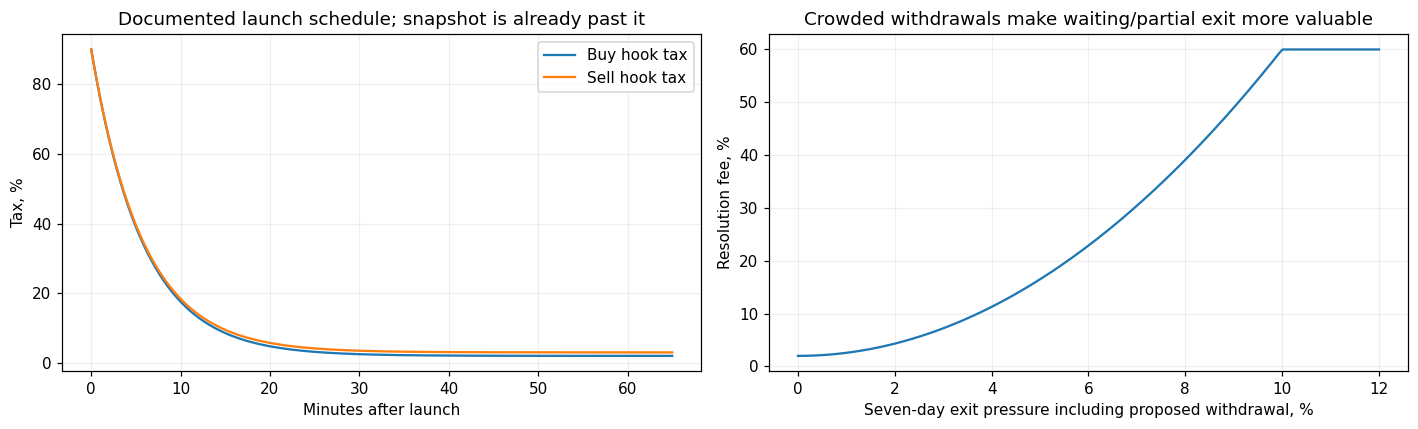

,resolution_fee,existing_branch_tokens_retained_after_withdraw_and_sale,cash_entry_to_branch_earnings_conversion_factor
0,0.0200,0.9411,0.9130
1,0.1600,0.8067,0.7826
2,0.6000,0.3841,0.3727


Wallet buy/sell round-trip factor before price impact: 0.9316830599999999
These are fee conversion factors; buying a license consumes principal, so they are not branch investment returns.


In [3]:
tax=home['snapshot']['tax'];launch=int(tax['taxDecayStart'])
minutes=np.linspace(0,65,400)
rates=np.array([rm.trading_taxes(launch+60*t,tax) for t in minutes])
fig,axes=plt.subplots(1,2,figsize=(13,4))
axes[0].plot(minutes,100*rates[:,0],label='Buy hook tax');axes[0].plot(minutes,100*rates[:,1],label='Sell hook tax')
axes[0].set(xlabel='Minutes after launch',ylabel='Tax, %',title='Documented launch schedule; snapshot is already past it');axes[0].legend()
pressure=np.linspace(0,.12,200)
fees=.02+.58*np.minimum(pressure/.1,1)**2
axes[1].plot(100*pressure,100*fees)
axes[1].set(xlabel='Seven-day exit pressure including proposed withdrawal, %',ylabel='Resolution fee, %',title='Crowded withdrawals make waiting/partial exit more valuable')
fig.tight_layout();fig.savefig(OUT/'tax-schedules.png',dpi=160);plt.show()
fee_rows=[]
for f in [.02,.16,.60]:
    fee_rows.append(dict(resolution_fee=f,
        existing_branch_tokens_retained_after_withdraw_and_sale=(1-f)*.99*.97,
        cash_entry_to_branch_earnings_conversion_factor=.98*.99*(1-f)*.99*.97))
display(pd.DataFrame(fee_rows))
print('Wallet buy/sell round-trip factor before price impact:',.98*.99*.99*.97)
print('These are fee conversion factors; buying a license consumes principal, so they are not branch investment returns.')

## 3. The choices actors make

For a Charter with $n$ branches and balance $B$, the model estimates the best discounted withdrawal cash over a set of horizons:

$$V(n,B)=\max_t e^{-dt}\,\operatorname{SellQuote}_{P_t,L_t}\!\left((B+\text{projected earnings}_t)(1-f_t)\right).$$

Earnings use the actor's share of projected system branches. Quotes use the actual range structure, not one constant-k curve. Future prices are capped by what the modeled available ETH could finance—a necessary feasibility bound, not proof that buyers will spend it.

The feasible actions are compared as follows:

1. **Keep the branches:** retain $V(n,B)$.
2. **Use ledger earnings:** buy only if $V(n+1,B-c)>V(n,B)$.
3. **Use wallet tokens/cash:** buy only if the extra value exceeds inventory opportunity cost plus the actual ETH needed to buy missing tokens.
4. **Retire some/all branches:** compare immediate net cash plus the remaining position's continuation value with holding. Transactions execute sequentially, so later actors face the changed price and congestion fee.
5. **Prefund:** buy inventory only when an assumed future eligible license is attractive and buying tokens now beats the forecast later purchase cost. Expected allocation is bounded by available slots and daily supply; inventory purchases are recorded separately from license consumption.

Speculators use fee-adjusted reservation prices, finite wallets and per-period participation limits. The population contains momentum-following and mean-reverting cohorts with different cash/token allocations. These differences are assumptions about beliefs, not evidence that either group knows the future.

The value function uses a limited forecast and action set. It does not solve the complete sequence of future reinvestments or a full strategic equilibrium. All banker agents are assumed to check in, avoiding the documented 30-day dormancy penalty.

In [4]:
# These are assumed wealth/belief parameters, not observed wallet balances.
assumptions=pd.DataFrame([
 ('Banker ETH budget',BASE.banker_cash_eth,'distributed across observed Charters'),
 ('Speculator ETH budget',BASE.speculator_cash_eth,'finite cash held outside the pool at the start'),
 ('Prospective Charter buyer budget',BASE.prospective_charter_cash_eth,'used only if ETH Charter auctions open'),
 ('Banker share of outside-pool token proxy',BASE.banker_token_fraction,'prefunded inventory assumption'),
 ('Mean-reverting fraction of speculative cohorts',BASE.mean_reverter_fraction,'belief diversity assumption'),
 ('Momentum-cohort share of speculative cash',BASE.momentum_cohort_cash_share,'capital distribution assumption'),
 ('Momentum-cohort share of speculative tokens',BASE.momentum_cohort_token_share,'inventory distribution assumption'),
 ('Prior expected daily log return',BASE.prior_growth_day,'belief, not fitted expected return'),
 ('Belief dispersion per day',BASE.belief_dispersion_day,'fixed across the path for each actor'),
 ('Weight on observed momentum',BASE.momentum_weight,'positive for followers, negative for mean reverters'),
 ('Daily time/risk discount',BASE.discount_day,'subjective opportunity cost'),
 ('Valuation horizon in days',BASE.valuation_days,'also tested for consistency/terminal-tail sensitivity'),
],columns=['Assumption','Value','Meaning'])
display(assumptions)

,Assumption,Value,Meaning
0,Banker ETH budget,"2,000.0000",distributed across observed Charters
1,Speculator ETH budget,"10,000.0000",finite cash held outside the pool at the start
2,Prospective Charter buyer budget,"1,000.0000",used only if ETH Charter auctions open
3,Banker share of outside-pool token proxy,0.0200,prefunded inventory assumption
4,Mean-reverting fraction of speculative cohorts,0.3500,belief diversity assumption
5,Momentum-cohort share of speculative cash,0.8500,capital distribution assumption
6,Momentum-cohort share of speculative tokens,0.2500,inventory distribution assumption
7,Prior expected daily log return,0.0200,"belief, not fitted expected return"
8,Belief dispersion per day,0.0400,fixed across the path for each actor
9,Weight on observed momentum,0.2500,"positive for followers, negative for mean reve..."


## 4. Scenarios: separate the mechanisms

The default keeps current trading taxes, the 100/day license quota, and ETH Charter auctions closed. It adds **no capital beyond the explicitly assumed starting budgets**. Existing wallet tokens can be sold and the cash reused, but reused money is not counted as a new external contribution.

The Charter-opening scenario is hypothetical: opens after 48 hours, ten new Charters/day, 0.45 ETH first opening and 0.15 ETH floor. A new Charter is sold only if its forecast first-branch value covers the price and its buyer has the cash. Future expansion-option value is omitted from that bid, a conservative simplification.

The protocol-execution scenario assumes the required owner/keeper actions and TWAP checks permit execution. It applies spending caps, normal buy taxes by default and explicit fee routing. POL deployment proportionally extends known ranges; future actual range placement is unknown. Existing locked LP stays safe in every scenario.

In [5]:
configs=[
 replace(BASE,name='Adaptive; Charters closed'),
 replace(BASE,name='ETH Charters open at +48h',charter_open_hour=48),
 replace(BASE,name='Buybacks and POL executed',execute_buybacks=True,execute_pol=True),
 replace(BASE,name='Additional 3,000 ETH/day',fresh_capital_eth_day=3000),
 replace(BASE,name='Flat price beliefs',prior_growth_day=0,belief_dispersion_day=0,momentum_weight=0),
 replace(BASE,name='External funding only',allow_internal=False),
 replace(BASE,name='10% buy and sell taxes',buy_tax_override=.10,sell_tax_override=.10),
 replace(BASE,name='No initial banker cash/inventory',banker_cash_eth=0,banker_token_fraction=0),
]
config_table=pd.DataFrame([asdict(c) for c in configs])
display(config_table[['name','license_daily_cap','banker_cash_eth','banker_token_fraction','allow_internal',
    'fresh_capital_eth_day','charter_open_hour','execute_buybacks','execute_pol','buy_tax_override','sell_tax_override']].fillna('unchanged/disabled'))

,name,license_daily_cap,banker_cash_eth,banker_token_fraction,allow_internal,fresh_capital_eth_day,charter_open_hour,execute_buybacks,execute_pol,buy_tax_override,sell_tax_override
0,Adaptive; Charters closed,100,2000,0.0200,True,0,unchanged/disabled,False,False,unchanged/disabled,unchanged/disabled
1,ETH Charters open at +48h,100,2000,0.0200,True,0,48.0000,False,False,unchanged/disabled,unchanged/disabled
2,Buybacks and POL executed,100,2000,0.0200,True,0,unchanged/disabled,True,True,unchanged/disabled,unchanged/disabled
3,"Additional 3,000 ETH/day",100,2000,0.0200,True,3000,unchanged/disabled,False,False,unchanged/disabled,unchanged/disabled
4,Flat price beliefs,100,2000,0.0200,True,0,unchanged/disabled,False,False,unchanged/disabled,unchanged/disabled
5,External funding only,100,2000,0.0200,False,0,unchanged/disabled,False,False,unchanged/disabled,unchanged/disabled
6,10% buy and sell taxes,100,2000,0.0200,True,0,unchanged/disabled,False,False,0.1000,0.1000
7,No initial banker cash/inventory,100,0,0.0000,True,0,unchanged/disabled,False,False,unchanged/disabled,unchanged/disabled


In [6]:
runs={};started=time.time()
for c in configs:
    runs[c.name]=[rm.simulate(c,SEED+i) for i in range(PATHS)]
    print(c.name,':',PATHS,'paths completed;',round(time.time()-started,1),'seconds elapsed',flush=True)
frames={name:[x['frame'] for x in paths] for name,paths in runs.items()}
hours=frames[configs[0].name][0].hour.to_numpy()
assert all(np.array_equal(f.hour.to_numpy(),hours) for fs in frames.values() for f in fs)

Adaptive; Charters closed : 12 paths completed; 61.6 seconds elapsed


ETH Charters open at +48h : 12 paths completed; 126.1 seconds elapsed


Buybacks and POL executed : 12 paths completed; 188.4 seconds elapsed


Additional 3,000 ETH/day : 12 paths completed; 259.3 seconds elapsed


Flat price beliefs : 12 paths completed; 306.6 seconds elapsed


External funding only : 12 paths completed; 368.8 seconds elapsed


10% buy and sell taxes : 12 paths completed; 431.9 seconds elapsed


No initial banker cash/inventory : 12 paths completed; 492.9 seconds elapsed


## 5. Does the model now generate an early top?

It can, but does not require one through a prescribed buying-decay schedule. A reversal can arise when willing buyers exhaust cash, their expected return no longer covers taxes, auctions become unattractive, returns are sold, or beliefs change. Fresh capital and protocol purchases can change that outcome.

**No mixture probability or single “most likely” top is assigned.** Seed ranges describe these assumed populations only. A best time at the final observation is unresolved. The protected wallet and representative one-branch Charter remain unsold in the population until their hypothetical evaluation; they are not also sold by the crowd.

,scenario,median_peak_h,p10_peak_h,p90_peak_h,best_precommitted_wallet_h,wallet_date_JST,mean_wallet_ETH,wallet_now_ETH,fraction_below_selling_now,best_protected_branch_h,mean_protected_branch_ETH,branch_boundary_optimum,median_final_price_ratio,fraction_peak_at_horizon
0,Adaptive; Charters closed,31.0000,31.0000,31.0000,31.0000,Sep 17 02:09 JST,56.5429,17.6856,0.0000,327.0000,0.9182,False,1.3685,0.0000
1,ETH Charters open at +48h,31.0000,31.0000,31.0000,31.0000,Sep 17 02:09 JST,56.5483,17.6856,0.0000,327.0000,1.1706,False,1.4194,0.0000
2,Buybacks and POL executed,31.0000,31.0000,31.0000,31.0000,Sep 17 02:09 JST,56.5429,17.6856,0.0000,130.0000,0.9140,False,0.9926,0.0000
3,"Additional 3,000 ETH/day",233.0000,173.2000,335.1000,237.0000,Sep 25 16:09 JST,72.1666,17.6856,0.0000,327.0000,2.9904,False,3.1507,0.1667
4,Flat price beliefs,0.0000,0.0000,0.0000,0.0000,Sep 15 19:09 JST,17.6856,17.6856,0.0000,336.0000,0.0754,True,0.0706,0.0000
5,External funding only,31.0000,31.0000,31.0000,31.0000,Sep 17 02:09 JST,57.4186,17.6856,0.0000,207.0000,0.8184,False,0.6308,0.0000
6,10% buy and sell taxes,31.0000,31.0000,31.0000,31.0000,Sep 17 02:09 JST,47.3691,16.4093,0.0000,31.0000,0.4903,False,0.4007,0.0000
7,No initial banker cash/inventory,31.0000,31.0000,31.0000,31.0000,Sep 17 02:09 JST,54.5796,17.6856,0.0000,114.0000,0.7531,False,0.5301,0.0000


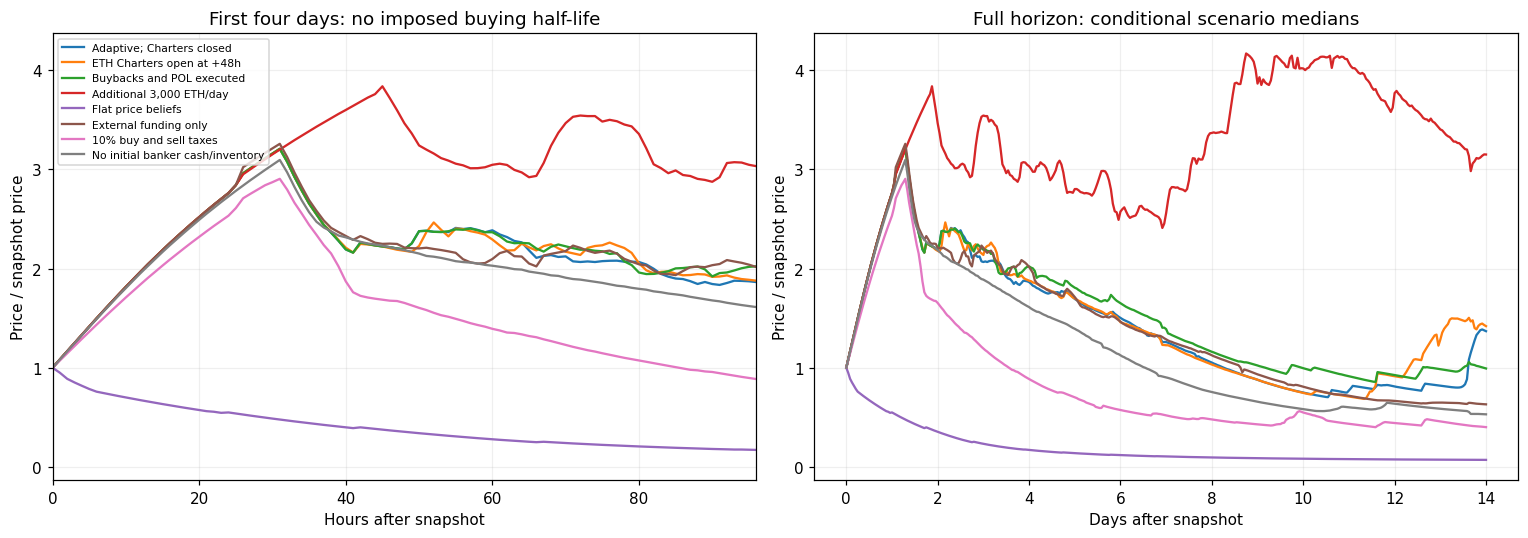

In [7]:
curve=rm.ConcentratedPool(snapshot['liquidity_profile']).curve
summary=[];wallet_cash={};branch_cash={};price_paths={}
for name,fs in frames.items():
    prices=np.stack([f.price.to_numpy() for f in fs]);price_paths[name]=prices
    wc=[];bc=[]
    for f in fs:
        wc.append(curve.sell_quotes(f.sqrt.to_numpy(),WALLET_TOKENS,f.scale.to_numpy(),snapshot['lp_fee'],f.sell_tax.to_numpy()))
        fee=rm.resolution_fee(f.protected_branch_balance.to_numpy(),f.pending.to_numpy(),f.withdrawn_7d.to_numpy())
        bc.append(curve.sell_quotes(f.sqrt.to_numpy(),f.protected_branch_balance.to_numpy()*(1-fee),f.scale.to_numpy(),snapshot['lp_fee'],f.sell_tax.to_numpy()))
    wallet_cash[name]=np.stack(wc);branch_cash[name]=np.stack(bc)
    peaks=hours[np.argmax(prices,axis=1)];best=int(np.argmax(wallet_cash[name].mean(axis=0)))
    branch_best=int(np.argmax(branch_cash[name].mean(axis=0)))
    summary.append(dict(scenario=name,median_peak_h=float(np.median(peaks)),p10_peak_h=float(np.quantile(peaks,.1)),p90_peak_h=float(np.quantile(peaks,.9)),
        best_precommitted_wallet_h=float(hours[best]),wallet_date_JST=jst(hours[best]),mean_wallet_ETH=float(wallet_cash[name][:,best].mean()),
        wallet_now_ETH=float(wallet_cash[name][0,0]),fraction_below_selling_now=float(np.mean(wallet_cash[name][:,best]<wallet_cash[name][:,0])),
        best_protected_branch_h=float(hours[branch_best]),mean_protected_branch_ETH=float(branch_cash[name][:,branch_best].mean()),
        branch_boundary_optimum=bool(branch_best==len(hours)-1),
        median_final_price_ratio=float(np.median(prices[:,-1]/prices[:,0])),fraction_peak_at_horizon=float(np.mean(peaks==hours[-1]))))
summary=pd.DataFrame(summary);display(summary)
summary.to_csv(OUT/'scenario-summary.csv',index=False)
colors=plt.cm.tab10(np.arange(len(configs)))
fig,axes=plt.subplots(1,2,figsize=(14,5))
for c,color in zip(configs,colors):
    p=price_paths[c.name]/price_paths[c.name][:,[0]]
    axes[0].plot(hours,np.median(p,axis=0),label=c.name,color=color)
    axes[1].plot(hours/24,np.median(p,axis=0),color=color)
axes[0].set(xlim=(0,96),xlabel='Hours after snapshot',ylabel='Price / snapshot price',title='First four days: no imposed buying half-life')
axes[1].set(xlabel='Days after snapshot',ylabel='Price / snapshot price',title='Full horizon: conditional scenario medians')
axes[0].legend(fontsize=7);fig.tight_layout();fig.savefig(OUT/'agent-price-scenarios.png',dpi=160);plt.show()

## 6. Why does buying increase or decrease?

The charts distinguish speculative purchases, purchases specifically funding licenses, advance inventory purchases and protocol purchases. ETH paid for a new Charter is shown in the table separately: it enters the fee engine rather than the pool in that transaction.

All starting cash allocations are assumptions. A peak caused by spending an assumed 10,000 ETH budget does not establish that real buyers have only 10,000 ETH. The sensitivity section varies that constraint explicitly.

,scenario,speculative_buys_ETH,fresh_license_buys_ETH,prefund_buys_ETH,internal_licenses,external_licenses,new_charter_ETH,new_charters,buybacks_ETH,POL_buys_ETH,hook_tax_ETH,LP_input_ETH_fees,gross_withdrawn_tokens,resolution_fee_tokens,new_external_capital_ETH
0,Adaptive; Charters closed,"19,458.3468",902.0662,"1,904.9819",768.3333,631.6667,0.0000,0.0000,0.0000,0.0000,"1,083.8227",218.2009,"1,829,375.3531","487,221.1592",0.0000
1,ETH Charters open at +48h,"20,990.9233",856.0858,"2,156.5935",783.5000,616.5000,115.7914,122.5000,0.0000,0.0000,"1,163.1812",235.2353,"2,256,306.5384","671,798.0832",0.0000
2,Buybacks and POL executed,"19,450.9613",884.3074,"2,010.4869",798.8333,601.1667,0.0000,0.0000,372.3390,84.0985,"1,119.2287",223.4615,"1,971,105.8199","517,659.9905",0.0000
3,"Additional 3,000 ETH/day","47,655.6527",633.4697,"2,153.3301","1,003.8333",396.1667,0.0000,0.0000,0.0000,0.0000,"2,354.1991",494.3360,"1,575,577.5361","403,268.2059","42,000.0000"
4,Flat price beliefs,0.0000,210.4615,0.0000,796.0000,604.0000,0.0000,0.0000,0.0000,0.0000,106.1244,2.0625,"556,835.4307","49,414.0201",0.0000
5,External funding only,"15,702.6457","1,254.8461","1,639.2806",0.0000,"1,393.5833",0.0000,0.0000,0.0000,0.0000,940.2566,182.2484,"1,955,440.2283","445,688.1185",0.0000
6,10% buy and sell taxes,"13,228.1817",767.1843,869.5233,540.8333,859.1667,0.0000,0.0000,0.0000,0.0000,"2,945.9764",133.7840,"2,408,090.8516","796,931.2075",0.0000
7,No initial banker cash/inventory,"15,288.6145",0.8297,0.2548,"1,398.7500",1.2500,0.0000,0.0000,0.0000,0.0000,777.9752,149.8391,"1,890,679.3276","413,702.0962",0.0000


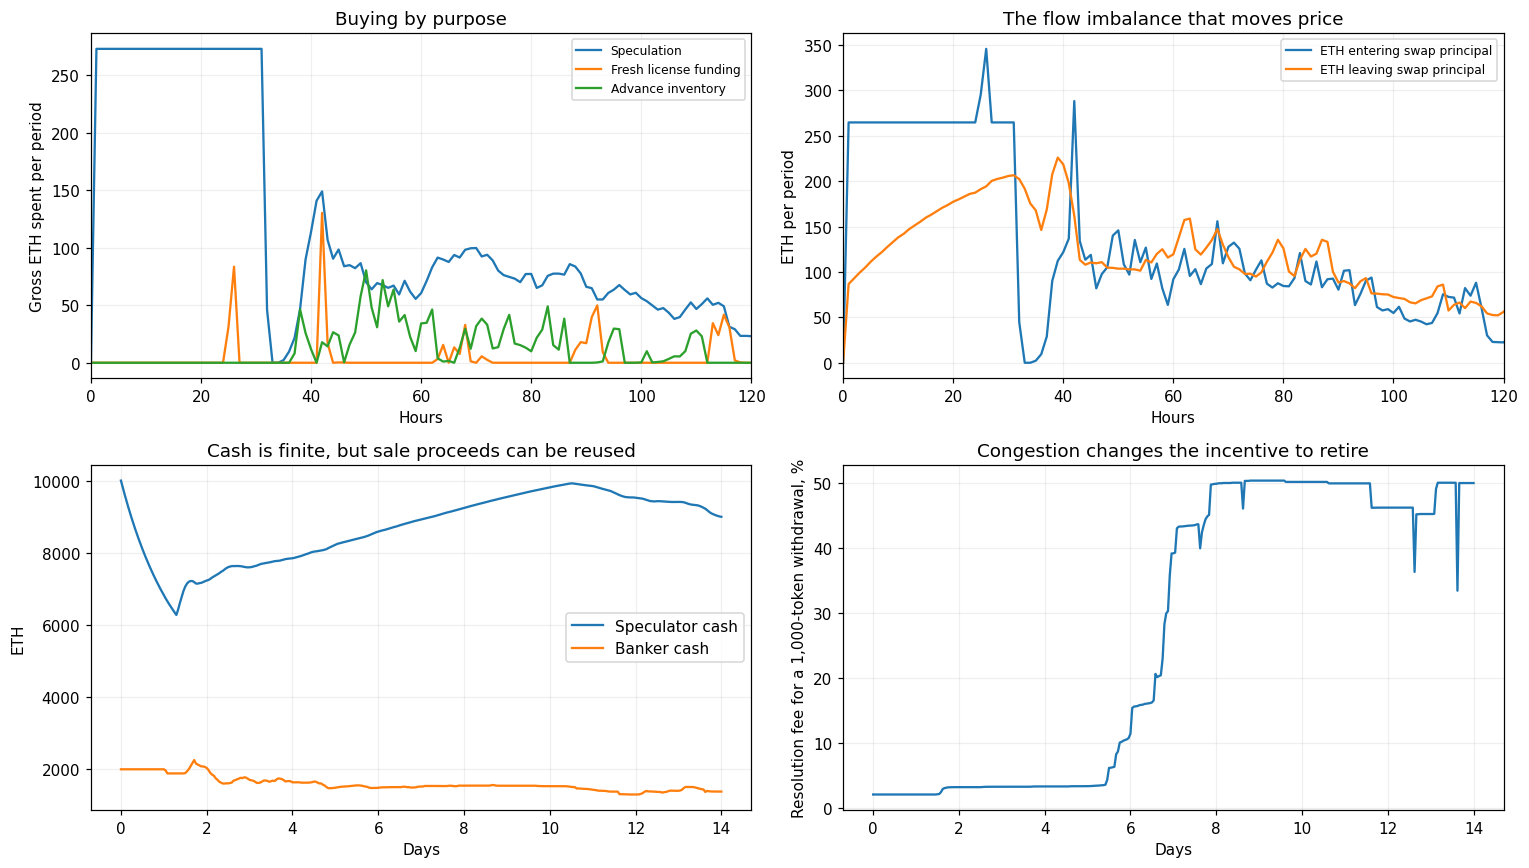

In [8]:
flow_rows=[]
for name,paths in runs.items():
    totals=pd.DataFrame([p['totals'] for p in paths]).mean()
    flow_rows.append(dict(scenario=name,speculative_buys_ETH=totals.spec_buy_eth,
        fresh_license_buys_ETH=totals.license_buy_eth,prefund_buys_ETH=totals.prefund_buy_eth,
        internal_licenses=totals.licenses_internal,external_licenses=totals.licenses_external,
        new_charter_ETH=totals.charter_eth,new_charters=totals.charters_created,
        buybacks_ETH=totals.buyback_eth,POL_buys_ETH=totals.pol_buy_eth,
        hook_tax_ETH=totals.hook_tax_eth,LP_input_ETH_fees=totals.lp_fee_eth,
        gross_withdrawn_tokens=totals.gross_withdrawn,resolution_fee_tokens=totals.resolution_fee_tokens,
        new_external_capital_ETH=totals.new_capital_eth))
flow_summary=pd.DataFrame(flow_rows);display(flow_summary)
flow_summary.to_csv(OUT/'funding-and-fees.csv',index=False)
name='Adaptive; Charters closed';fs=frames[name]
mean=pd.concat(fs).groupby('hour').mean(numeric_only=True)
fig,axes=plt.subplots(2,2,figsize=(14,8))
for col,label in [('spec_buy_eth','Speculation'),('license_buy_eth','Fresh license funding'),('prefund_buy_eth','Advance inventory')]:
    axes[0,0].plot(hours,mean[col],label=label)
axes[0,0].set(xlim=(0,120),xlabel='Hours',ylabel='Gross ETH spent per period',title='Buying by purpose');axes[0,0].legend(fontsize=8)
axes[0,1].plot(hours,mean.pool_buy_eth,label='ETH entering swap principal')
axes[0,1].plot(hours,mean.pool_sell_eth_gross,label='ETH leaving swap principal')
axes[0,1].set(xlim=(0,120),xlabel='Hours',ylabel='ETH per period',title='The flow imbalance that moves price');axes[0,1].legend(fontsize=8)
axes[1,0].plot(hours/24,mean.speculator_cash,label='Speculator cash');axes[1,0].plot(hours/24,mean.banker_cash,label='Banker cash')
axes[1,0].set(xlabel='Days',ylabel='ETH',title='Cash is finite, but sale proceeds can be reused');axes[1,0].legend()
axes[1,1].plot(hours/24,100*mean.resolution_fee_small)
axes[1,1].set(xlabel='Days',ylabel='Resolution fee for a 1,000-token withdrawal, %',title='Congestion changes the incentive to retire')
fig.tight_layout();fig.savefig(OUT/'agent-flow-drivers.png',dpi=160);plt.show()

## 7. Scarce branches, dilution, and ETH Charter sales

The same random seeds are used with Charter auctions closed and open. A new Charter brings an ETH payment and an initial branch; it can then compete for the unchanged global license quota. More Charter owners do not automatically mean more than 100 licenses/day are consumed.

The comparison measures the combined effects of access, dilution, funding, price and fees. It does not establish that delaying ETH auctions is universally optimal for either the team, incumbents or the token.

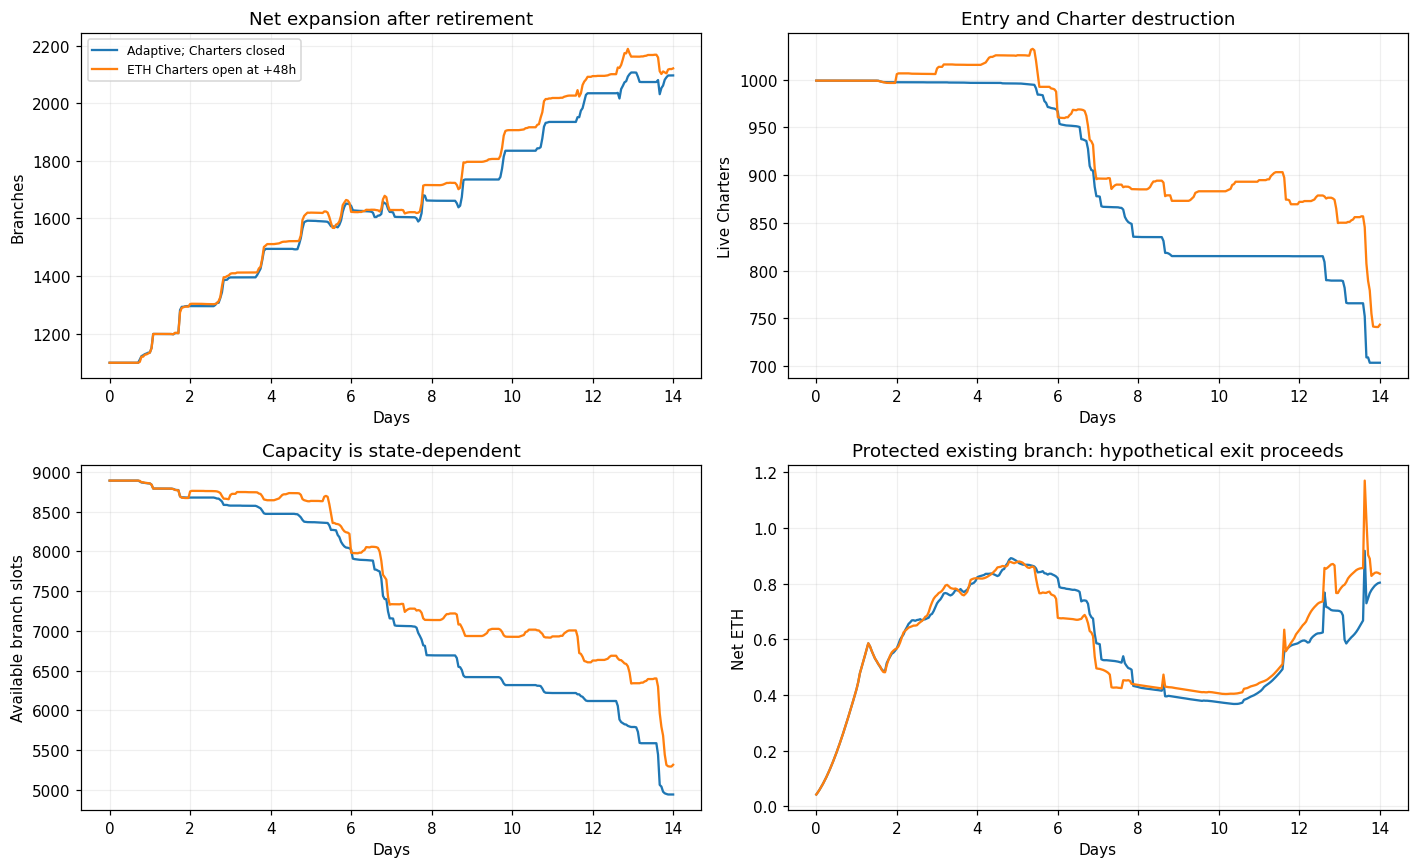

In [9]:
fig,axes=plt.subplots(2,2,figsize=(13,8))
for name in ['Adaptive; Charters closed','ETH Charters open at +48h']:
    mean=pd.concat(frames[name]).groupby('hour').mean(numeric_only=True)
    axes[0,0].plot(hours/24,mean.branches,label=name)
    axes[0,1].plot(hours/24,mean.charters,label=name)
    axes[1,0].plot(hours/24,mean.remaining_slots,label=name)
    axes[1,1].plot(hours/24,branch_cash[name].mean(axis=0),label=name)
axes[0,0].set(xlabel='Days',ylabel='Branches',title='Net expansion after retirement')
axes[0,1].set(xlabel='Days',ylabel='Live Charters',title='Entry and Charter destruction')
axes[1,0].set(xlabel='Days',ylabel='Available branch slots',title='Capacity is state-dependent')
axes[1,1].set(xlabel='Days',ylabel='Net ETH',title='Protected existing branch: hypothetical exit proceeds')
axes[0,0].legend(fontsize=8);fig.tight_layout();fig.savefig(OUT/'charter-policy-comparison.png',dpi=160);plt.show()

## 8. What would owners pay? What about funding someone else's Charter?

This worksheet evaluates marginal branch value at the snapshot under stated beliefs. It assumes a future auction opportunity, resetting the per-day eligibility counters for comparison; the actual first-day auction was sold out. The value is not a live executable offer.

The native interface gives a non-owner no independent branch-withdrawal right. The funding worksheet therefore assumes an agreement paying a share of the branch's incremental discounted cash value. Payment probability is an agreement assumption, not a risk haircut to locked LP. Real payout timing, aggregation of Charter fees and enforceability remain unspecified.

In [10]:
willingness=[];participation=[]
for label,overrides in [('Flat beliefs',dict(prior_growth_day=0,belief_dispersion_day=0,momentum_weight=0)),
                         ('Adaptive beliefs',{})]:
    e=rm.Economy(replace(BASE,protect_representative_branch=False,**overrides),SEED)
    e.used[:]=0;e.license_sold=0
    floor=e.c.floor_payback_days*e.issue_day/e.total_branches
    for multiple in [1,2,4,8,12,18.66]:
        cost=floor*multiple;ex,inside,_=e.license_surpluses(cost)
        willingness.append(dict(beliefs=label,license_price_tokens=cost,multiple_of_floor=multiple,
            profitable_and_fundable_charters=int(np.sum(np.maximum(ex,inside)>0)),
            prefer_ledger=int(np.sum((inside>=ex)&(inside>0))),prefer_external=int(np.sum((ex>inside)&(ex>0)))))
    n=np.array([1]);b=np.array([snapshot['own_pending']]);bias=np.array([e.c.prior_growth_day])
    old_value,_=e.values(n,b,bias);new_value,_=e.values(n+1,b,bias,total_branches=e.total_branches+1)
    delta=float(new_value[0]-old_value[0]);funding=e.pool.quote_buy(floor)
    for share,paid in [(1.,1.),(.8,1.),(.5,1.),(.8,.8)]:
        participation.append(dict(beliefs=label,payout_share=share,payment_probability=paid,
            marginal_branch_value_ETH=delta,full_market_funding_ETH=funding,
            expected_funder_net_ETH=share*paid*delta-funding,
            break_even_payout_share=funding/max(paid*delta,1e-20)))
display(pd.DataFrame(willingness));display(pd.DataFrame(participation))
pd.DataFrame(willingness).to_csv(OUT/'license-willingness-to-pay.csv',index=False)
pd.DataFrame(participation).to_csv(OUT/'third-party-value-worksheet.csv',index=False)

,beliefs,license_price_tokens,multiple_of_floor,profitable_and_fundable_charters,prefer_ledger,prefer_external
0,Flat beliefs,"1,273.8854",1.0000,999,33,966
1,Flat beliefs,"2,547.7707",2.0000,997,27,970
2,Flat beliefs,"5,095.5414",4.0000,995,24,971
3,Flat beliefs,"10,191.0828",8.0000,0,0,0
4,Flat beliefs,"15,286.6242",12.0000,0,0,0
5,Flat beliefs,"23,770.7006",18.6600,0,0,0
6,Adaptive beliefs,"1,273.8854",1.0000,999,0,999
7,Adaptive beliefs,"2,547.7707",2.0000,999,0,999
8,Adaptive beliefs,"5,095.5414",4.0000,999,0,999
9,Adaptive beliefs,"10,191.0828",8.0000,999,0,999


,beliefs,payout_share,payment_probability,marginal_branch_value_ETH,full_market_funding_ETH,expected_funder_net_ETH,break_even_payout_share
0,Flat beliefs,1.0000,1.0000,1.1921,0.2428,0.9492,0.2037
1,Flat beliefs,0.8000,1.0000,1.1921,0.2428,0.7108,0.2037
2,Flat beliefs,0.5000,1.0000,1.1921,0.2428,0.3532,0.2037
3,Flat beliefs,0.8000,0.8000,1.1921,0.2428,0.5201,0.2546
4,Adaptive beliefs,1.0000,1.0000,16.1458,0.2428,15.9030,0.0150
5,Adaptive beliefs,0.8000,1.0000,16.1458,0.2428,12.6738,0.0150
6,Adaptive beliefs,0.5000,1.0000,16.1458,0.2428,7.8301,0.0150
7,Adaptive beliefs,0.8000,0.8000,16.1458,0.2428,10.0905,0.0188


## 9. Sensitivity to capital and the license quota

The cash budget and beliefs must not become a disguised prediction. This grid varies the initial speculative ETH budget and the daily license quota. Other settings remain adaptive. Quotas different from 100 are policy counterfactuals. Each cell uses three common seeds and seven days.

The reported statistic is the peak of the mean price curve, not a probability. A result at day seven is censored by this shorter sensitivity horizon.

,speculator_budget_ETH,daily_license_cap,peak_of_mean_price_h,horizon_censored,mean_licenses,mean_fresh_license_ETH
0,2500,25,0.0000,False,175.0000,225.2126
1,2500,100,1.0000,False,700.0000,469.9549
2,2500,300,15.0000,False,"2,300.0000",782.6902
3,10000,25,31.0000,False,175.0000,203.0176
4,10000,100,31.0000,False,700.0000,760.3091
5,10000,300,31.0000,False,"2,300.0000","1,828.3208"
6,30000,25,31.0000,False,175.0000,190.9677
7,30000,100,31.0000,False,700.0000,935.0874
8,30000,300,31.0000,False,"2,300.0000","2,280.9305"


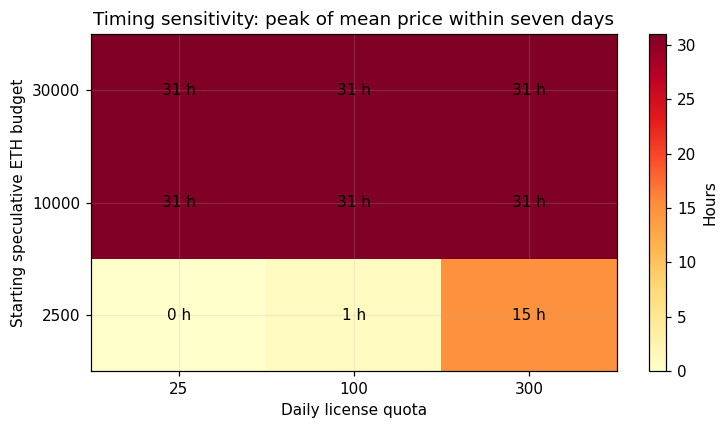

In [11]:
budgets=[2500,10000,30000];quotas=[25,100,300];sensitivity=[]
for budget in budgets:
    for quota in quotas:
        cfg=replace(BASE,days=7,speculator_cash_eth=budget,license_daily_cap=quota)
        paths=[rm.simulate(cfg,SEED+j) for j in range(3)]
        price=np.stack([x['frame'].price.to_numpy() for x in paths]);h=paths[0]['frame'].hour.to_numpy()
        best=int(np.argmax(price.mean(axis=0)))
        sensitivity.append(dict(speculator_budget_ETH=budget,daily_license_cap=quota,peak_of_mean_price_h=float(h[best]),
            horizon_censored=bool(best==len(h)-1),mean_licenses=float(np.mean([x['totals']['licenses_bought'] for x in paths])),
            mean_fresh_license_ETH=float(np.mean([x['totals']['license_buy_eth'] for x in paths]))))
sensitivity=pd.DataFrame(sensitivity);display(sensitivity)
sensitivity.to_csv(OUT/'capital-and-quota-sensitivity.csv',index=False)
grid=sensitivity.pivot(index='speculator_budget_ETH',columns='daily_license_cap',values='peak_of_mean_price_h')
fig,ax=plt.subplots(figsize=(7,4))
im=ax.imshow(grid.to_numpy(),aspect='auto',cmap='YlOrRd',origin='lower')
ax.set_xticks(range(len(quotas)),quotas);ax.set_yticks(range(len(budgets)),budgets)
for i in range(len(budgets)):
    for j in range(len(quotas)):ax.text(j,i,f'{grid.iloc[i,j]:.0f} h',ha='center',va='center')
ax.set(xlabel='Daily license quota',ylabel='Starting speculative ETH budget',title='Timing sensitivity: peak of mean price within seven days')
fig.colorbar(im,ax=ax,label='Hours');fig.tight_layout();fig.savefig(OUT/'capital-quota-sensitivity.png',dpi=160);plt.show()

## 10. Do the forecasts agree with the outcomes?

First compare each path's seven-day price expectation with the price subsequently generated by the model. Forecast error is important: a strategy can maximize its assumed return while relying on an inaccurate expectation.

Then perform a small consistency experiment. Start from a flat trial price/branch path, make actors optimize against it, simulate, and move the trial path halfway toward the resulting path. Repeat. Beyond seven days this experiment holds the trial price/branch count flat—a terminal-tail assumption. There is no guarantee of convergence, and convergence would not prove a complete Nash equilibrium. Only a limited set of forecasts and actions is being tested.

In [12]:
forecast_rows=[]
for name,fs in frames.items():
    errors=[]
    for f in fs:
        shift=int(7*24/BASE.dt_hours)
        actual=f.price.to_numpy()[shift:];predicted=f.forecast_price_7d.to_numpy()[:-shift]
        errors.extend(np.log(actual/predicted))
    forecast_rows.append(dict(scenario=name,mean_absolute_log_error=float(np.mean(np.abs(errors))),
                             median_actual_over_predicted=float(np.exp(np.median(errors)))))
forecast_errors=pd.DataFrame(forecast_rows);display(forecast_errors)
forecast_errors.to_csv(OUT/'forecast-errors.csv',index=False)
iteration,last=rm.consistency_iteration(replace(BASE,days=7,belief_dispersion_day=0),iterations=5,damping=.5,seed=SEED)
display(iteration)
iteration.to_csv(OUT/'consistency-iteration.csv',index=False)
if iteration.max_abs_log_price_error.iloc[-1]>.05:
    display(Markdown('**The iteration did not meet a 0.05 maximum log-price residual.** These runs do not establish self-consistent expectations; do not treat their peak as an equilibrium prediction.'))
else:
    display(Markdown('The tested iteration reaches a small price residual under its terminal-tail assumption. This is a numerical diagnostic, not proof of a strategic equilibrium.'))

,scenario,mean_absolute_log_error,median_actual_over_predicted
0,Adaptive; Charters closed,1.1810,0.4030
1,ETH Charters open at +48h,1.1427,0.4072
2,Buybacks and POL executed,1.1020,0.4367
3,"Additional 3,000 ETH/day",0.7720,0.9827
4,Flat price beliefs,1.0443,0.4092
5,External funding only,1.1598,0.4188
6,10% buy and sell taxes,1.0388,0.6354
7,No initial banker cash/inventory,1.1959,0.3921


,iteration,max_abs_log_price_error,peak_h,last_price_ratio
0,1,0.0696,139.0000,0.9802
1,2,0.0405,163.0000,0.9704
2,3,0.0461,139.0000,0.9602
3,4,0.0800,0.0000,0.9510
4,5,0.0658,163.0000,0.9415


**The iteration did not meet a 0.05 maximum log-price residual.** These runs do not establish self-consistent expectations; do not treat their peak as an equilibrium prediction.

## 11. Accounting, provenance, and limits

Every path checks ETH, physical tokens, and internal ledger claims. Only the explicit capital-arrival setting adds external ETH. Purchases transfer cash into the pool, sales remove it, hook taxes enter the fee buffer, LP fees accrue separately, and team/vault/POL allocations stay separately tracked. Internal license purchases remove ledger claims; externally funded licenses burn physical tokens. Withdrawal fees are not double-counted as cash.

Limits that matter: assumed actor wealth and beliefs; coarse forecast horizons; approximate future branch/withdrawal expectations; simplified prefunding allocation; no gas/MEV; no full future-action dynamic program; no full source/runtime audit. Protocol execution is conditional on availability and TWAP gates, with future POL range placement approximated. LP fees remain uncollected in this experiment. All modeled bankers check in; there is no forced dormancy loss. The quota/cash sensitivity and consistency test are therefore central results, not optional footnotes.

In [13]:
audit=[]
for name,paths in runs.items():
    for j,path in enumerate(paths):
        f=path['frame']
        audit.append(dict(scenario=name,seed=SEED+j,
            max_ETH_error=float(f.eth_accounting_error.abs().max()),
            max_token_error=float(f.token_accounting_error.abs().max()),
            max_ledger_error=float(f.ledger_accounting_error.abs().max())))
        assert f.eth_accounting_error.abs().max()<1e-5
        assert f.token_accounting_error.abs().max()<.02
        assert f.ledger_accounting_error.abs().max()<1e-5
        assert (f.remaining_slots==10*f.charters-f.branches).all()
        assert (f.protected_branch_count==1).all()
        np.testing.assert_allclose(f.eth_principal.diff().iloc[1:],(f.pool_buy_eth-f.pool_sell_eth_gross+f.pol_added_eth).iloc[1:],atol=1e-6)
audit=pd.DataFrame(audit);display(audit.groupby('scenario').max(numeric_only=True).drop(columns='seed'))
audit.to_csv(OUT/'accounting-checks.csv',index=False)
# Save mean trajectories plus one complete example/event ledger per scenario.
for index,c in enumerate(configs):
    label=f'{index+1:02d}'
    mean=pd.concat(frames[c.name]).groupby('hour').mean(numeric_only=True)
    mean.to_csv(OUT/f'{label}-mean-path.csv')
    runs[c.name][0]['frame'].to_csv(OUT/f'{label}-example-path.csv',index=False)
    runs[c.name][0]['events'].to_csv(OUT/f'{label}-example-events.csv',index=False)
    runs[c.name][0]['final_population'].to_csv(OUT/f'{label}-final-charters.csv',index=False)
metadata=dict(snapshot_utc=str(start),block=complete['block'],block_hash=complete['hash'],paths=PATHS,seed=SEED,
    scenarios=[asdict(c) for c in configs],summary=summary.to_dict('records'),
    interpretation='Profit-seeking actions under explicit beliefs; no imposed demand half-life, no fitted scenario probabilities, no equilibrium guarantee.',
    source_sha256={n:hashlib.sha256((ROOT/n).read_bytes()).hexdigest() for n in ['rational_model.py','model.py','liquidity.py']},
    evidence_sha256={n:hashlib.sha256((old.EVIDENCE/n).read_bytes()).hexdigest() for n in ['home.json','state.json','charters.json','liquidity-ticks.json','liquidity-positions.json']})
(OUT/'run-metadata.json').write_text(json.dumps(metadata,indent=2,allow_nan=False)+'\n')
print('Saved model configuration, curves, event ledgers, accounting checks and diagnostics to',OUT.name)

,max_ETH_error,max_token_error,max_ledger_error
scenario,,,
10% buy and sell taxes,0.0000,0.0000,0.0000
Adaptive; Charters closed,0.0000,0.0000,0.0000
"Additional 3,000 ETH/day",0.0000,0.0000,0.0000
Buybacks and POL executed,0.0000,0.0000,0.0000
ETH Charters open at +48h,0.0000,0.0000,0.0000
External funding only,0.0000,0.0000,0.0000
Flat price beliefs,0.0000,0.0000,0.0000
No initial banker cash/inventory,0.0000,0.0000,0.0000


Saved model configuration, curves, event ledgers, accounting checks and diagnostics to agent-results
